In [2]:
import sys
import os
import pandas as pd
import numpy as np
from pycox.models.cox import CoxPH
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt
import torchtuples as tt
import shap
import scipy.integrate
scipy.integrate.simps = scipy.integrate.simpson
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.compare import compare_survival
from sksurv.util import Surv
from itertools import product
import torch

sys.path.append(os.path.abspath("../../"))
from src.dataset.generate_dataset import TorchPreprocessing
from src.dataset.DataSet import SurvivalDataSet
from src.utils.Preprocessing import Preprocessor
from src.utils.ConvertTextToCsv import TextToCsv
from src.dataset.split_data import split_data_Train_Val_Test
from src.utils.set_seed import set_seed
from src.utils.plots import Plots
from src.utils.cox_models import *



import numpy as np
import torch


%load_ext autoreload
%autoreload 2
%matplotlib inline

/Users/administrador/Library/Python/3.11/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
set_seed(42)

In [4]:
pp = Preprocessor()
plots_class = Plots()

In [5]:
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()
df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")
clean_mRNA_df = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")


Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 299 - Total(%) 0.37
Shape of the CSV: (20440, 819)
Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818


In [6]:
total_columns = len(df_mRNA_raw_data) - 50

df_merged = TorchPreprocessing(df_mRNA_raw_data,df_clinical_data, total_columns).get_comparation_df()
 
comparation_df = df_merged.loc[
    df_merged["Tumor-Cancer"].isin(["Luminal A", "Luminal B", "TNBC", "HER2-enriched"]),
]
comparation_df["Tumor-Cancer"].unique()



Genes before Treshold: 20393
count    20393.000000
mean        74.057471
std        155.640823
min          0.000000
25%          0.000000
50%          0.000000
75%         21.000000
max        519.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 18492


array(['Luminal A', 'TNBC', 'Luminal B', 'HER2-enriched'], dtype=object)

In [7]:
status = comparation_df["Overall Survival Status"].astype(str).str.strip()

comparation_df["event"] = status.str.contains("DECEASED", na=False)

comparation_df["event_60"] = comparation_df["event"].copy()

comparation_df["time_60"] =  np.minimum(comparation_df["Overall Survival (Months)"], 60)

comparation_df.loc[
    comparation_df["Overall Survival (Months)"] > 60, "event_60"
] = False

comparation_df = comparation_df.dropna(subset=["time_60"]).copy()



In [8]:
comparation_df

,Tumor-Cancer,Sample ID,Overall Survival Status,Overall Survival (Months),YTHDF1,HCLS1,BBS4,B3GNT8,SLC25A13,TGFBI,...,IFITM4P,OCEL1,SRRM2,SUGP2,ARMT1,MOXD1,LRRC36,event,event_60,time_60
2,Luminal A,TCGA-A1-A0SE-01,0:LIVING,43.400000,1333.1139,427.4784,530.8104,113.8626,435.0473,1496.9971,...,0.0000,392.2666,14806.7462,1041.2242,1463.1016,190.5389,8.8852,False,False,43.400000
6,Luminal A,TCGA-A1-A0SJ-01,0:LIVING,13.670000,6435.1166,660.2652,415.1806,103.8866,548.6968,4431.2757,...,0.0000,215.8208,9176.7718,506.2643,1416.0037,161.6827,3.2922,False,False,13.670000
7,TNBC,TCGA-A1-A0SK-01,1:DECEASED,31.770000,2198.2351,91.3962,129.2153,42.8616,767.0974,2496.6908,...,0.0000,42.2313,8408.7614,3846.8925,469.2720,128.9001,12.9215,True,True,31.770000
8,Luminal B,TCGA-A1-A0SM-01,0:LIVING,7.950000,1636.6793,796.0859,540.0884,104.4823,749.6843,5092.1717,...,0.0000,280.3030,7811.2374,1142.6831,642.3611,176.1364,31.8813,False,False,7.950000
10,TNBC,TCGA-A1-A0SP-01,0:LIVING,19.190000,1824.1518,853.3382,121.4885,32.8347,1177.3076,2913.5352,...,0.3648,118.9347,10679.6789,1539.2448,650.1277,1538.4896,4.3780,False,False,19.190000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
812,Luminal A,TCGA-MS-A51U-01,0:LIVING,22.370000,1806.4684,686.4893,526.3432,138.2368,272.3005,2382.8899,...,0.5216,547.7308,20787.1622,3602.0083,676.0563,130.9338,6.7814,False,False,22.370000
813,Luminal A,TCGA-OL-A66H-01,0:LIVING,26.695598,1242.7023,1670.9758,372.3937,121.3511,614.2619,5536.2802,...,0.4170,406.1718,6897.8315,1074.6455,3351.9600,200.5838,4.1701,False,False,26.695598
814,TNBC,TCGA-OL-A66I-01,0:LIVING,23.460000,2076.1607,3009.2853,193.2186,37.5587,715.7016,3280.5425,...,0.4173,222.0136,5936.3589,1577.4648,385.1852,1213.5629,1.2520,False,False,23.460000
815,Luminal A,TCGA-OL-A66J-01,0:LIVING,65.570000,1484.0018,706.1740,495.2681,291.5728,313.2041,1334.3849,...,0.0000,540.7841,7480.3966,1342.9473,11103.6503,125.7323,6.7598,False,False,60.000000


In [9]:
# Lista de genes asociados a ER (Tabla 3 del paper publicado: 16 genes).
# El enunciado mencionaba "20 genes"; se asume confusion y se trabaja con
# los 16 de la unica tabla publicada disponible.
predefined_genes = [
    "TBC1D9", "SUSD3", "SLC39A6", "GFRA1", "SOX11", "GATA3",
    "SLC15A2", "CCDC170", "NANOS1", "ZNF552", "ESR1", "NAT1",
    "NME3", "DNALI1", "AGR3", "CA12",
]
genes_disponibles = set(comparation_df.columns)   


presentes = [g for g in predefined_genes if g in genes_disponibles]
faltan    = [g for g in predefined_genes if g not in genes_disponibles]

print("Presentes:", presentes)
print("Faltan:", faltan)

Presentes: ['TBC1D9', 'SUSD3', 'SLC39A6', 'GFRA1', 'SOX11', 'GATA3', 'SLC15A2', 'CCDC170', 'NANOS1', 'ZNF552', 'ESR1', 'NAT1', 'NME3', 'DNALI1', 'AGR3', 'CA12']
Faltan: []


In [10]:
ids_comparation_df = comparation_df["Sample ID"]
df_comparation_df_corte = df_clinical_data[df_clinical_data["Sample ID"].isin(ids_comparation_df)].copy()
df_comparation_df_corte

,Sample ID,Patient ID,Overall Survival (Months),Overall Survival Status,Diagnosis Age,Neoplasm Disease Stage American Joint Committee on Cancer Code,Lymph Node(s) Examined Number,Menopause Status,ER Status By IHC,PR status by ihc,HER2 fish status,HER2 ihc score,Tumor-Cancer
2,TCGA-A1-A0SE-01,TCGA-A1-A0SE,43.400000,0:LIVING,56.0,Stage I,8.0,Pre (<6 months since LMP AND no prior bilatera...,Positive,Positive,Negative,1.0,Luminal A
6,TCGA-A1-A0SJ-01,TCGA-A1-A0SJ,13.670000,0:LIVING,39.0,Stage IIIA,19.0,NaN,Positive,Positive,Negative,2.0,Luminal A
7,TCGA-A1-A0SK-01,TCGA-A1-A0SK,31.770000,1:DECEASED,54.0,Stage IIA,4.0,Indeterminate (neither Pre or Postmenopausal),Negative,Negative,NaN,0.0,TNBC
8,TCGA-A1-A0SM-01,TCGA-A1-A0SM,7.950000,0:LIVING,77.0,Stage IIA,3.0,NaN,Positive,Negative,Positive,3.0,Luminal B
10,TCGA-A1-A0SP-01,TCGA-A1-A0SP,19.190000,0:LIVING,40.0,Stage IIA,3.0,NaN,Negative,Negative,NaN,0.0,TNBC
...,...,...,...,...,...,...,...,...,...,...,...,...,...
813,TCGA-MS-A51U-01,TCGA-MS-A51U,22.370000,0:LIVING,44.0,Stage IIB,18.0,NaN,Positive,Positive,Negative,NaN,Luminal A
814,TCGA-OL-A66H-01,TCGA-OL-A66H,26.695598,0:LIVING,NaN,Stage IB,1.0,Post (prior bilateral ovariectomy OR >12 mo si...,Positive,Positive,Negative,NaN,Luminal A
815,TCGA-OL-A66I-01,TCGA-OL-A66I,23.460000,0:LIVING,36.0,Stage IIA,13.0,NaN,Negative,Negative,Negative,NaN,TNBC
816,TCGA-OL-A66J-01,TCGA-OL-A66J,65.570000,0:LIVING,80.0,Stage I,4.0,Post (prior bilateral ovariectomy OR >12 mo si...,Positive,Positive,Negative,NaN,Luminal A


threshold = 7479.6178

For this group the risk TBC1D9+

For the time 0 the risk group is 255
For the time 12 the risk group is 218
For the time 24 the risk group is 128
For the time 36 the risk group is 95
For the time 48 the risk group is 68
For the time 60 the risk group is 48

For this group the risk TBC1D9-

For the time 0 the risk group is 254
For the time 12 the risk group is 221
For the time 24 the risk group is 138
For the time 36 the risk group is 93
For the time 48 the risk group is 70
For the time 60 the risk group is 51


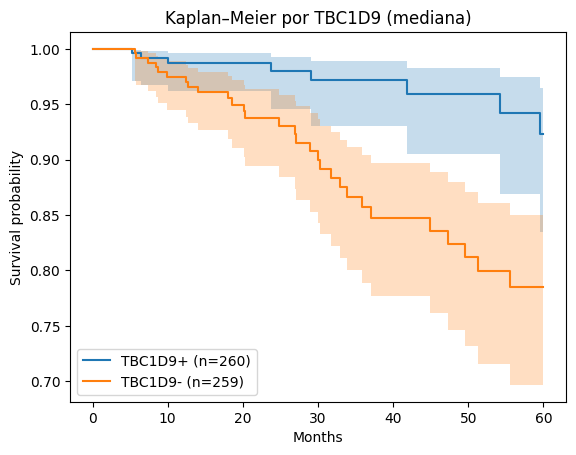

Log-rank: chi2=11.754, p=0.0006071
FINISH of the ==============TBC1D9======================
threshold = 676.1256

For this group the risk SUSD3+

For the time 0 the risk group is 257
For the time 12 the risk group is 224
For the time 24 the risk group is 131
For the time 36 the risk group is 91
For the time 48 the risk group is 62
For the time 60 the risk group is 47

For this group the risk SUSD3-

For the time 0 the risk group is 252
For the time 12 the risk group is 215
For the time 24 the risk group is 135
For the time 36 the risk group is 97
For the time 48 the risk group is 76
For the time 60 the risk group is 52


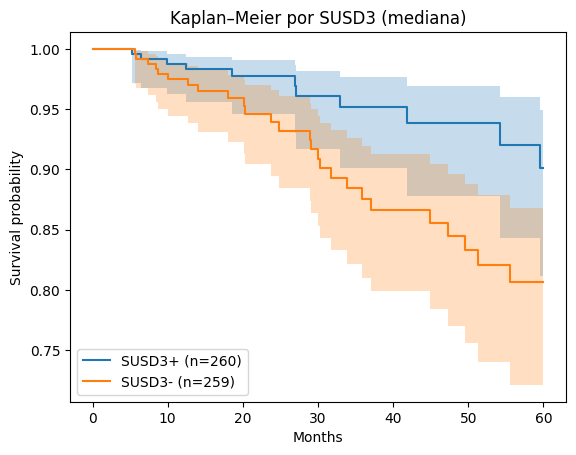

Log-rank: chi2=5.552, p=0.01846
FINISH of the ==============SUSD3======================
threshold = 12910.5114

For this group the risk SLC39A6+

For the time 0 the risk group is 257
For the time 12 the risk group is 224
For the time 24 the risk group is 132
For the time 36 the risk group is 94
For the time 48 the risk group is 65
For the time 60 the risk group is 46

For this group the risk SLC39A6-

For the time 0 the risk group is 252
For the time 12 the risk group is 215
For the time 24 the risk group is 134
For the time 36 the risk group is 94
For the time 48 the risk group is 73
For the time 60 the risk group is 53


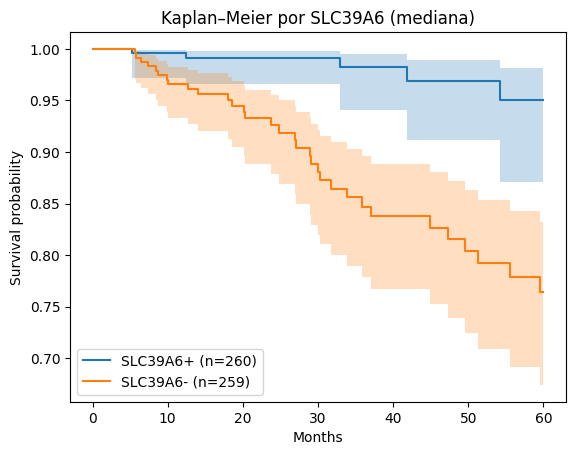

Log-rank: chi2=19.528, p=9.913e-06
FINISH of the ==============SLC39A6======================
threshold = 4851.9204

For this group the risk GFRA1+

For the time 0 the risk group is 257
For the time 12 the risk group is 224
For the time 24 the risk group is 136
For the time 36 the risk group is 97
For the time 48 the risk group is 70
For the time 60 the risk group is 54

For this group the risk GFRA1-

For the time 0 the risk group is 252
For the time 12 the risk group is 215
For the time 24 the risk group is 130
For the time 36 the risk group is 91
For the time 48 the risk group is 68
For the time 60 the risk group is 45


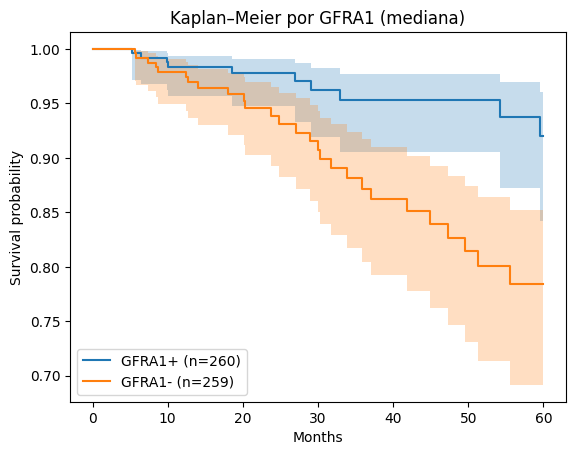

Log-rank: chi2=8.905, p=0.002843
FINISH of the ==============GFRA1======================
threshold = 41.9521

For this group the risk SOX11+

For the time 0 the risk group is 255
For the time 12 the risk group is 216
For the time 24 the risk group is 127
For the time 36 the risk group is 88
For the time 48 the risk group is 66
For the time 60 the risk group is 47

For this group the risk SOX11-

For the time 0 the risk group is 254
For the time 12 the risk group is 223
For the time 24 the risk group is 139
For the time 36 the risk group is 100
For the time 48 the risk group is 72
For the time 60 the risk group is 52


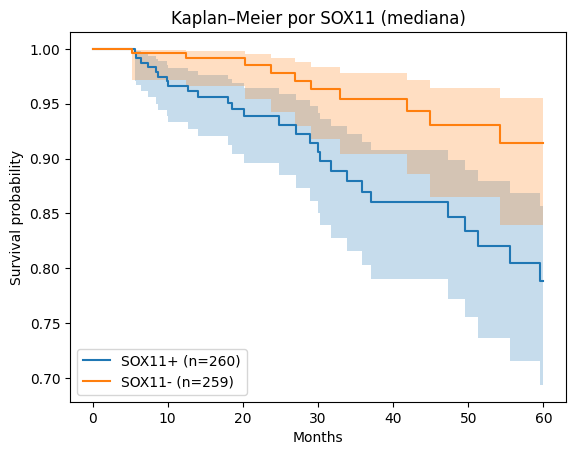

Log-rank: chi2=9.205, p=0.002414
FINISH of the ==============SOX11======================
threshold = 10722.2546

For this group the risk GATA3+

For the time 0 the risk group is 254
For the time 12 the risk group is 219
For the time 24 the risk group is 137
For the time 36 the risk group is 95
For the time 48 the risk group is 66
For the time 60 the risk group is 47

For this group the risk GATA3-

For the time 0 the risk group is 255
For the time 12 the risk group is 220
For the time 24 the risk group is 129
For the time 36 the risk group is 93
For the time 48 the risk group is 72
For the time 60 the risk group is 52


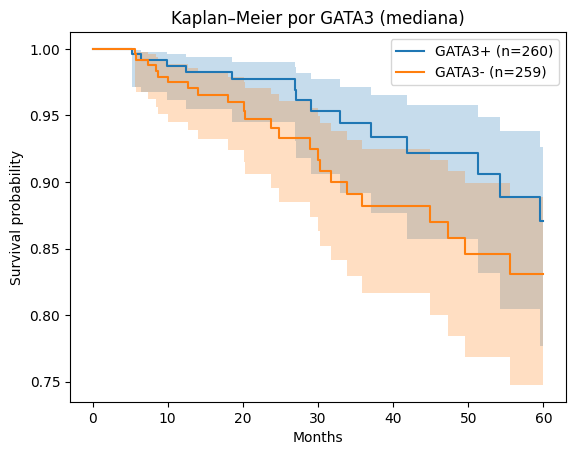

Log-rank: chi2=2.112, p=0.1462
FINISH of the ==============GATA3======================
threshold = 70.2346

For this group the risk SLC15A2+

For the time 0 the risk group is 256
For the time 12 the risk group is 218
For the time 24 the risk group is 133
For the time 36 the risk group is 96
For the time 48 the risk group is 73
For the time 60 the risk group is 52

For this group the risk SLC15A2-

For the time 0 the risk group is 253
For the time 12 the risk group is 221
For the time 24 the risk group is 133
For the time 36 the risk group is 92
For the time 48 the risk group is 65
For the time 60 the risk group is 47


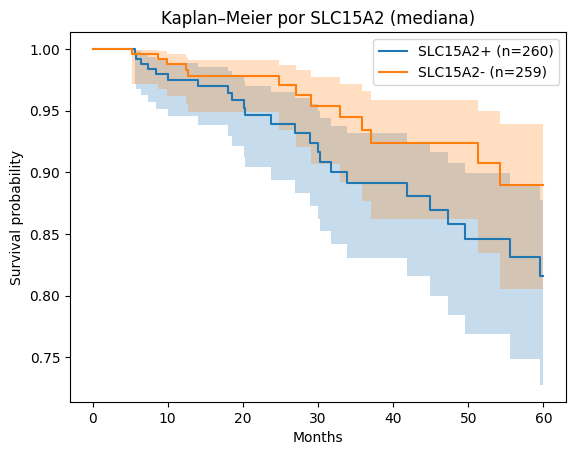

Log-rank: chi2=2.815, p=0.09341
FINISH of the ==============SLC15A2======================
threshold = 394.7368

For this group the risk CCDC170+

For the time 0 the risk group is 255
For the time 12 the risk group is 223
For the time 24 the risk group is 126
For the time 36 the risk group is 91
For the time 48 the risk group is 63
For the time 60 the risk group is 43

For this group the risk CCDC170-

For the time 0 the risk group is 254
For the time 12 the risk group is 216
For the time 24 the risk group is 140
For the time 36 the risk group is 97
For the time 48 the risk group is 75
For the time 60 the risk group is 56


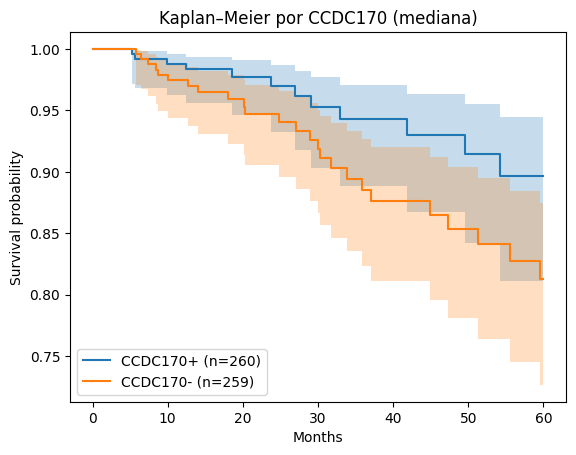

Log-rank: chi2=3.614, p=0.05729
FINISH of the ==============CCDC170======================
threshold = 192.2538

For this group the risk NANOS1+

For the time 0 the risk group is 255
For the time 12 the risk group is 216
For the time 24 the risk group is 128
For the time 36 the risk group is 88
For the time 48 the risk group is 67
For the time 60 the risk group is 48

For this group the risk NANOS1-

For the time 0 the risk group is 254
For the time 12 the risk group is 223
For the time 24 the risk group is 138
For the time 36 the risk group is 100
For the time 48 the risk group is 71
For the time 60 the risk group is 51


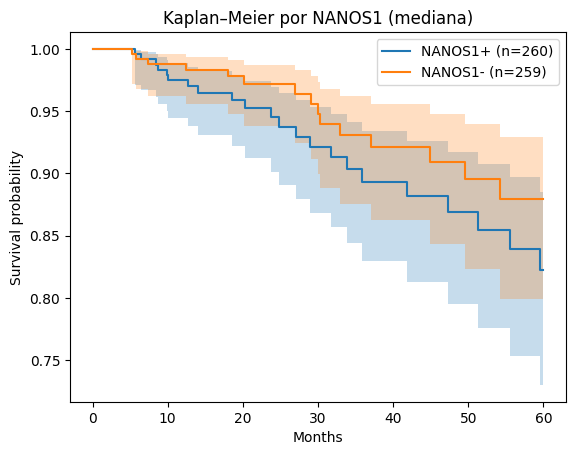

Log-rank: chi2=1.670, p=0.1962
FINISH of the ==============NANOS1======================
threshold = 1197.519

For this group the risk ZNF552+

For the time 0 the risk group is 255
For the time 12 the risk group is 225
For the time 24 the risk group is 136
For the time 36 the risk group is 94
For the time 48 the risk group is 65
For the time 60 the risk group is 44

For this group the risk ZNF552-

For the time 0 the risk group is 254
For the time 12 the risk group is 214
For the time 24 the risk group is 130
For the time 36 the risk group is 94
For the time 48 the risk group is 73
For the time 60 the risk group is 55


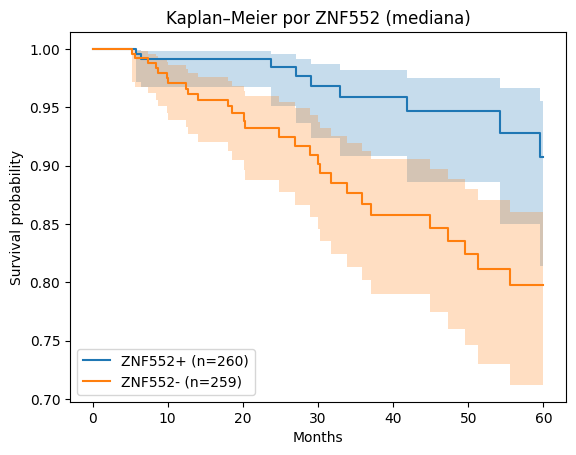

Log-rank: chi2=9.531, p=0.00202
FINISH of the ==============ZNF552======================
threshold = 7515.7695

For this group the risk ESR1+

For the time 0 the risk group is 254
For the time 12 the risk group is 223
For the time 24 the risk group is 129
For the time 36 the risk group is 88
For the time 48 the risk group is 59
For the time 60 the risk group is 40

For this group the risk ESR1-

For the time 0 the risk group is 255
For the time 12 the risk group is 216
For the time 24 the risk group is 137
For the time 36 the risk group is 100
For the time 48 the risk group is 79
For the time 60 the risk group is 59


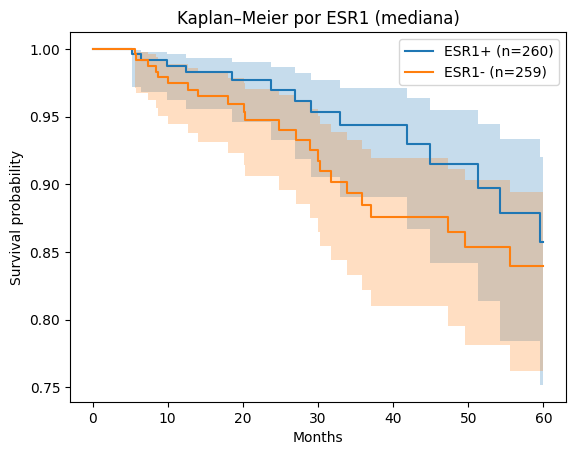

Log-rank: chi2=1.477, p=0.2242
FINISH of the ==============ESR1======================
threshold = 1165.8805

For this group the risk NAT1+

For the time 0 the risk group is 256
For the time 12 the risk group is 220
For the time 24 the risk group is 131
For the time 36 the risk group is 93
For the time 48 the risk group is 66
For the time 60 the risk group is 50

For this group the risk NAT1-

For the time 0 the risk group is 253
For the time 12 the risk group is 219
For the time 24 the risk group is 135
For the time 36 the risk group is 95
For the time 48 the risk group is 72
For the time 60 the risk group is 49


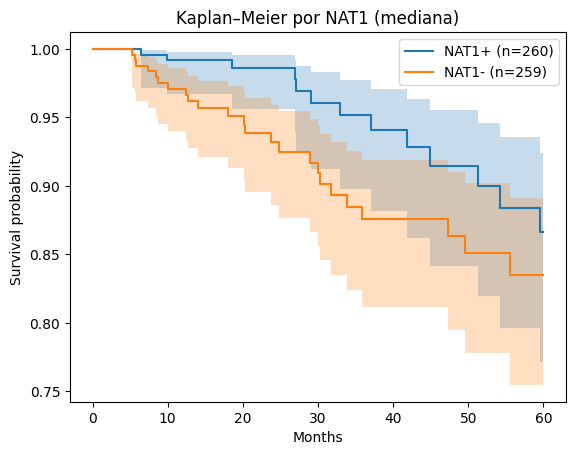

Log-rank: chi2=3.144, p=0.07622
FINISH of the ==============NAT1======================
threshold = 790.5064

For this group the risk NME3+

For the time 0 the risk group is 257
For the time 12 the risk group is 224
For the time 24 the risk group is 138
For the time 36 the risk group is 96
For the time 48 the risk group is 67
For the time 60 the risk group is 50

For this group the risk NME3-

For the time 0 the risk group is 252
For the time 12 the risk group is 215
For the time 24 the risk group is 128
For the time 36 the risk group is 92
For the time 48 the risk group is 71
For the time 60 the risk group is 49


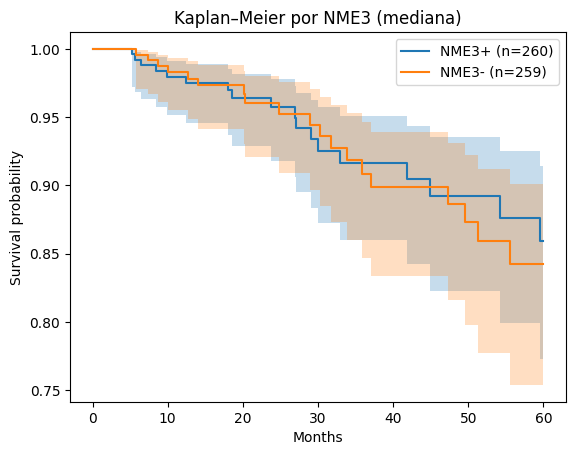

Log-rank: chi2=0.059, p=0.8073
FINISH of the ==============NME3======================
threshold = 802.0625

For this group the risk DNALI1+

For the time 0 the risk group is 254
For the time 12 the risk group is 220
For the time 24 the risk group is 138
For the time 36 the risk group is 102
For the time 48 the risk group is 73
For the time 60 the risk group is 51

For this group the risk DNALI1-

For the time 0 the risk group is 255
For the time 12 the risk group is 219
For the time 24 the risk group is 128
For the time 36 the risk group is 86
For the time 48 the risk group is 65
For the time 60 the risk group is 48


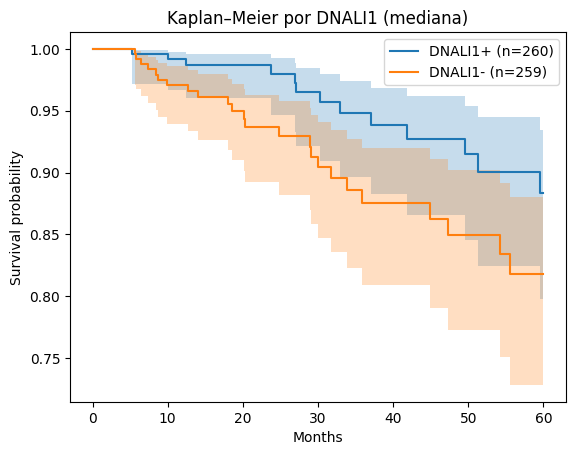

Log-rank: chi2=4.177, p=0.04098
FINISH of the ==============DNALI1======================
threshold = 1599.0611

For this group the risk AGR3+

For the time 0 the risk group is 256
For the time 12 the risk group is 221
For the time 24 the risk group is 131
For the time 36 the risk group is 89
For the time 48 the risk group is 65
For the time 60 the risk group is 47

For this group the risk AGR3-

For the time 0 the risk group is 253
For the time 12 the risk group is 218
For the time 24 the risk group is 135
For the time 36 the risk group is 99
For the time 48 the risk group is 73
For the time 60 the risk group is 52


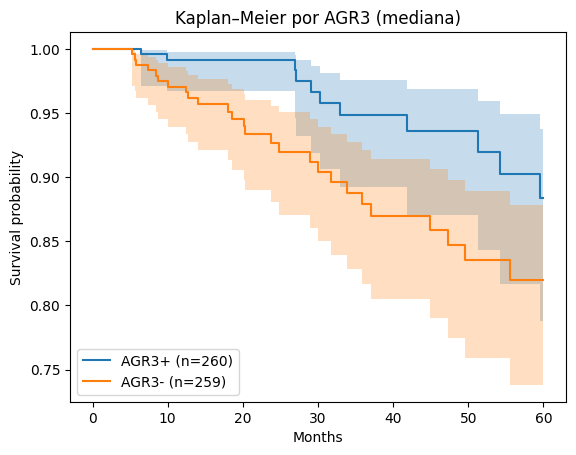

Log-rank: chi2=5.523, p=0.01877
FINISH of the ==============AGR3======================
threshold = 8099.6036

For this group the risk CA12+

For the time 0 the risk group is 255
For the time 12 the risk group is 222
For the time 24 the risk group is 136
For the time 36 the risk group is 93
For the time 48 the risk group is 65
For the time 60 the risk group is 43

For this group the risk CA12-

For the time 0 the risk group is 254
For the time 12 the risk group is 217
For the time 24 the risk group is 130
For the time 36 the risk group is 95
For the time 48 the risk group is 73
For the time 60 the risk group is 56


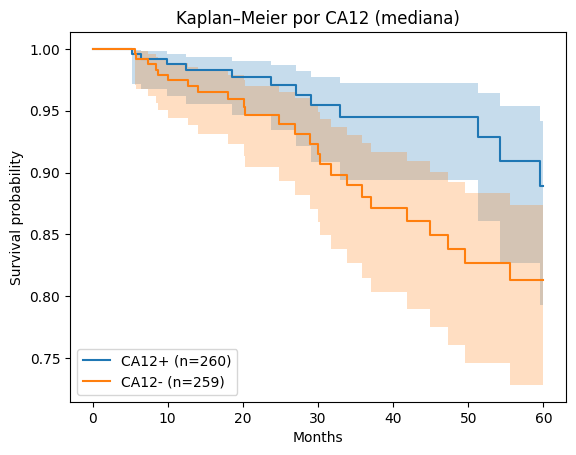

Log-rank: chi2=4.324, p=0.03759
FINISH of the ==============CA12======================


In [11]:


genes_p_chi_values = []
for gene in presentes:
    chi_values, p_value_values = plots_class.plot_kaplan_meier(
        df_mrna=clean_mRNA_df,
        df_clin=df_comparation_df_corte,
        time_col="Overall Survival (Months)",
        status_col="Overall Survival Status",
        gene=gene,
        form="median"
    )
    
    genes_p_chi_values.append({
        "gene":gene,
        "p-value":p_value_values,
        "chi-value":chi_values
    })
    
    print(f"FINISH of the =============={gene}======================")
    


In [12]:
df_genes_p_chi_values = pd.DataFrame(genes_p_chi_values)

In [13]:
df_genes_p_chi_values = df_genes_p_chi_values.sort_values("p-value").reset_index(drop=True)
df_genes_p_chi_values  

,gene,p-value,chi-value
0,SLC39A6,0.000010,19.528171
1,TBC1D9,0.000607,11.754216
2,ZNF552,0.002020,9.530837
3,SOX11,0.002414,9.204918
4,GFRA1,0.002843,8.905388
5,SUSD3,0.018459,5.552025
6,AGR3,0.018767,5.523112
7,CA12,0.037588,4.323578
8,DNALI1,0.040978,4.176940
9,CCDC170,0.057293,3.614053


### PyCox

In [14]:
cox_uni_results = []
X_candidates = np.log2(comparation_df[presentes].apply(pd.to_numeric, errors='coerce') + 1)
for gene in presentes:
    try:
        df_gene = pd.DataFrame({
            'gene': X_candidates[gene],
            'time': comparation_df['time_60'],
            'event': comparation_df['event_60']
        }).dropna()
        
        cph = CoxPHFitter()
        cph.fit(df_gene, duration_col='time', event_col='event')
        
        cox_uni_results.append({
            'gene': gene,
            'beta': cph.params_['gene'],
            'p_value': cph.summary['p']['gene'],
        })
    except Exception:
        continue  



In [15]:
cox_uni_df = pd.DataFrame(cox_uni_results)
cox_uni_df

,gene,beta,p_value
0,TBC1D9,-0.235291,0.001433
1,SUSD3,-0.233702,0.001079
2,SLC39A6,-0.322619,0.001118
3,GFRA1,-0.146574,0.000330
4,SOX11,0.158241,0.009846
5,GATA3,-0.180468,0.002626
6,SLC15A2,0.196513,0.021728
7,CCDC170,-0.251666,0.000333
8,NANOS1,0.356704,0.026688
9,ZNF552,-0.401210,0.000124


In [ ]:
cox_uni_df = pd.DataFrame(cox_uni_results)

tabla_final = (df_genes_p_chi_values.rename(columns={"p-value": "logrank_p"}).merge(cox_uni_df.rename(columns={"beta": "beta_unicox","p_value": "p_unicox"}),on="gene").sort_values("logrank_p").reset_index(drop=True)
)
tabla_final

,gene,logrank_p,chi-value,beta_unicox,p_unicox
0,SLC39A6,0.000010,19.528171,-0.322619,0.001118
1,TBC1D9,0.000607,11.754216,-0.235291,0.001433
2,ZNF552,0.002020,9.530837,-0.401210,0.000124
3,SOX11,0.002414,9.204918,0.158241,0.009846
4,GFRA1,0.002843,8.905388,-0.146574,0.000330
5,SUSD3,0.018459,5.552025,-0.233702,0.001079
6,AGR3,0.018767,5.523112,-0.110999,0.001712
7,CA12,0.037588,4.323578,-0.181019,0.001118
8,DNALI1,0.040978,4.176940,-0.188949,0.000927
9,CCDC170,0.057293,3.614053,-0.251666,0.000333
